In [3]:
!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv -O lead_scoring.csv

--2026-07-24 15:37:48--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80876 (79K) [text/plain]
Saving to: ‘lead_scoring.csv’

lead_scoring.csv    100%[===================>]  78.98K   299KB/s    in 0.3s    

2026-07-24 15:37:49 (299 KB/s) - ‘lead_scoring.csv’ saved [80876/80876]



In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

%matplotlib inline

In [5]:
df = pd.read_csv('lead_scoring.csv')

In [6]:
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [7]:
df.shape

(1462, 9)

In [8]:
df.dtypes

lead_source                     str
industry                        str
number_of_courses_viewed      int64
annual_income               float64
employment_status               str
location                        str
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [9]:
categorical = [
    'lead_source',
    'industry',
    'employment_status',
    'location'
]

numerical = [
    'number_of_courses_viewed',
    'annual_income',
    'interaction_count',
    'lead_score'
]

In [10]:
for col in categorical:
    df[col] = df[col].fillna('NA')
    
for col in numerical:
    df[col] = df[col].fillna(0.0)


df.isnull().sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction import DictVectorizer

In [12]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [13]:
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

del df_train['converted']
del df_val['converted']
del df_test['converted']

X_train = df_train[numerical + categorical]
X_val = df_val[numerical + categorical]
X_test = df_test[numerical + categorical]

### Question 1: ROC AUC feature importance

In [14]:
from sklearn.metrics import roc_auc_score

for col in numerical:
    auc = roc_auc_score(y_train, df_train[col])

    if auc < 0.5:
        auc = roc_auc_score(y_train, -df_train[col])

    print('%-28s %.3f' % (col, auc))

number_of_courses_viewed     0.764
annual_income                0.552
interaction_count            0.738
lead_score                   0.614


In [15]:
dv = DictVectorizer(sparse=False)
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)

train_dict = X_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

model.fit(X_train, y_train)

,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalt

In [16]:
val_dict = X_val.to_dict(orient='records')
X_val = dv.transform(val_dict)

model.score(X_val, y_val)

0.6996587030716723

In [17]:
y_pred = model.predict_proba(X_val)[:, 1]

converted_decision = y_pred > 0.5
(y_val == converted_decision).mean()

np.float64(0.6996587030716723)

### Question 2: Training the model

In [18]:
auc = roc_auc_score(y_val, y_pred)
round(auc, 3)

0.817

In [19]:
from sklearn.metrics import accuracy_score

In [20]:
tresholds = np.linspace(0, 1, 11)

In [21]:
scores = []
for treshold in tresholds:
    
    # converted_descition = y_pred > treshold
    
    # score = (y_val == converted_descition).mean()
    
    score = accuracy_score(y_val, y_pred > treshold)
    
    print("{} - {}".format(treshold.round(2), score))
    
    scores.append((treshold, score))

0.0 - 0.5836177474402731
0.1 - 0.5836177474402731
0.2 - 0.5836177474402731
0.3 - 0.5938566552901023
0.4 - 0.6416382252559727
0.5 - 0.6996587030716723
0.6 - 0.7474402730375427
0.7 - 0.6928327645051194
0.8 - 0.6143344709897611
0.9 - 0.4948805460750853
1.0 - 0.41638225255972694


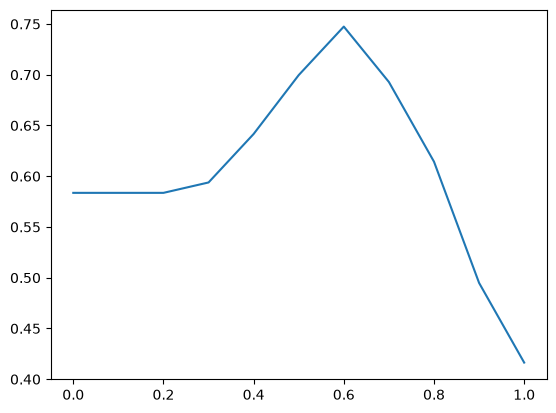

In [22]:
plt.plot(*zip(*scores))

### Cross Validation

In [23]:
from sklearn.model_selection import KFold

In [24]:
kf = KFold(n_splits=5, shuffle=True, random_state=1)

for train_idx, val_idx in kf.split(df_full_train):
    
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]
    
    y_train = df_train.converted.values
    y_val = df_val.converted.values
    
    del df_train['converted']
    del df_val['converted']
    
    X_train = df_train[numerical + categorical]
    X_val = df_val[numerical + categorical]
    
    train_dict = X_train.to_dict(orient='records')
    X_train = dv.fit_transform(train_dict)
    
    model.fit(X_train, y_train)
    
    val_dict = X_val.to_dict(orient='records')
    X_val = dv.transform(val_dict)
    
    y_pred = model.predict_proba(X_val)[:, 1]
    
    auc = roc_auc_score(y_val, y_pred)
    print(auc)
    
    
    

0.8060745924216483
0.8713738368910783
0.7754320118852139
0.8018368617683685
0.8558272713202291


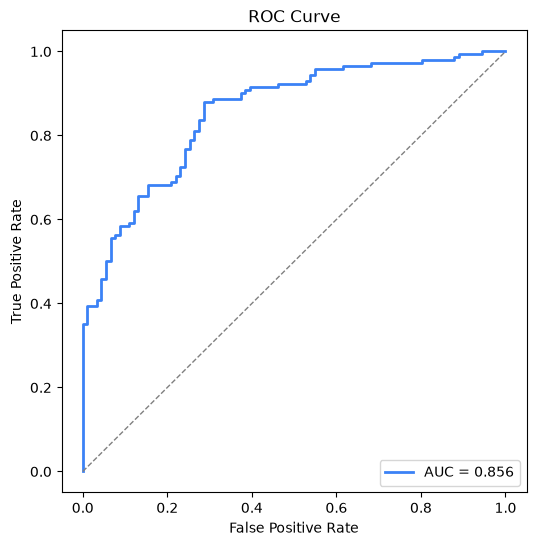

In [25]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt


fpr, tpr, thresholds = roc_curve(y_val, y_pred)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="#3b82f6", linewidth=2, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)  # random model chizig'i

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()